In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [3]:
df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print(df.info())

print("\nShape:", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistics")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Shape: (891, 12)

Missing Values
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          

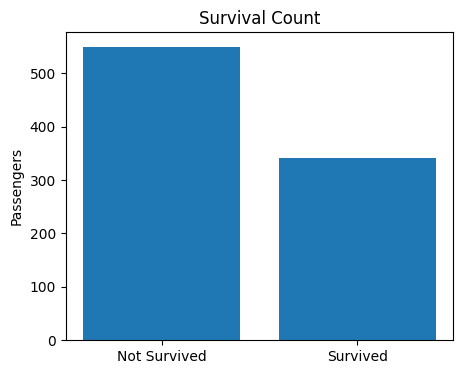

In [5]:
survival = df["Survived"].value_counts()

plt.figure(figsize=(5,4))
plt.bar(["Not Survived","Survived"], survival)

plt.title("Survival Count")
plt.ylabel("Passengers")
plt.show()

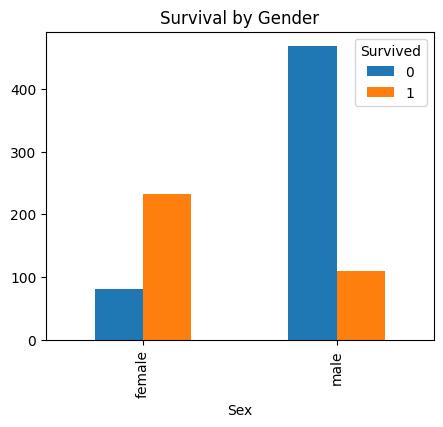

In [6]:
gender = pd.crosstab(df["Sex"],df["Survived"])

gender.plot(kind="bar",figsize=(5,4))

plt.title("Survival by Gender")
plt.show()

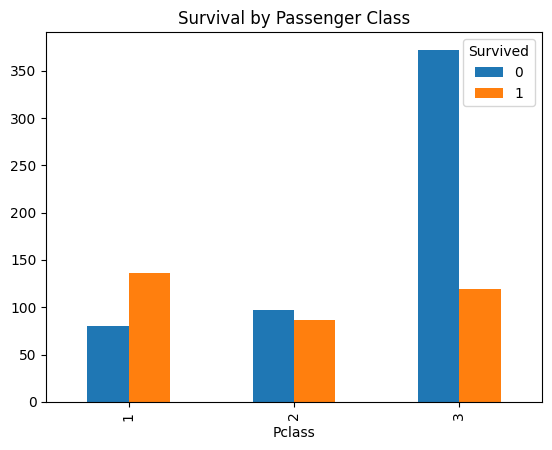

In [7]:
pclass = pd.crosstab(df["Pclass"],df["Survived"])

pclass.plot(kind="bar")

plt.title("Survival by Passenger Class")
plt.show()

In [8]:
df["Age"].fillna(df["Age"].median(), inplace=True)

df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

df.drop("Cabin", axis=1, inplace=True)

/tmp/ipykernel_687/851712005.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipykernel_687/851712005.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [9]:
# Family Size
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Is Alone
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# Encode Gender
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])

# Encode Embarked
df["Embarked"] = LabelEncoder().fit_transform(df["Embarked"])

In [10]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone"
]

X = df[features]

y = df["Survived"]

In [11]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(712, 7)
(179, 7)


In [12]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test,lr_pred)

print("Logistic Regression Accuracy")

print(lr_accuracy)

Logistic Regression Accuracy
0.7988826815642458


In [13]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test,rf_pred)

print("Random Forest Accuracy")

print(rf_accuracy)

Random Forest Accuracy
0.8324022346368715


In [14]:
print("Logistic Regression Accuracy :",lr_accuracy)

print("Random Forest Accuracy :",rf_accuracy)

Logistic Regression Accuracy : 0.7988826815642458
Random Forest Accuracy : 0.8324022346368715


In [15]:
print("Logistic Regression Accuracy :",lr_accuracy)

print("Random Forest Accuracy :",rf_accuracy)

Logistic Regression Accuracy : 0.7988826815642458
Random Forest Accuracy : 0.8324022346368715


In [16]:
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [17]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86       105
           1       0.81      0.78      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179



In [18]:
print("Logistic Regression")

print(confusion_matrix(y_test,lr_pred))

print()

print("Random Forest")

print(confusion_matrix(y_test,rf_pred))

Logistic Regression
[[90 15]
 [21 53]]

Random Forest
[[91 14]
 [16 58]]
